Total tweets: 61,121

Sentiment counts:
sentiment
Negative    22358
Positive    20655
Neutral     18108
Name: count, dtype: int64

Brands: 32


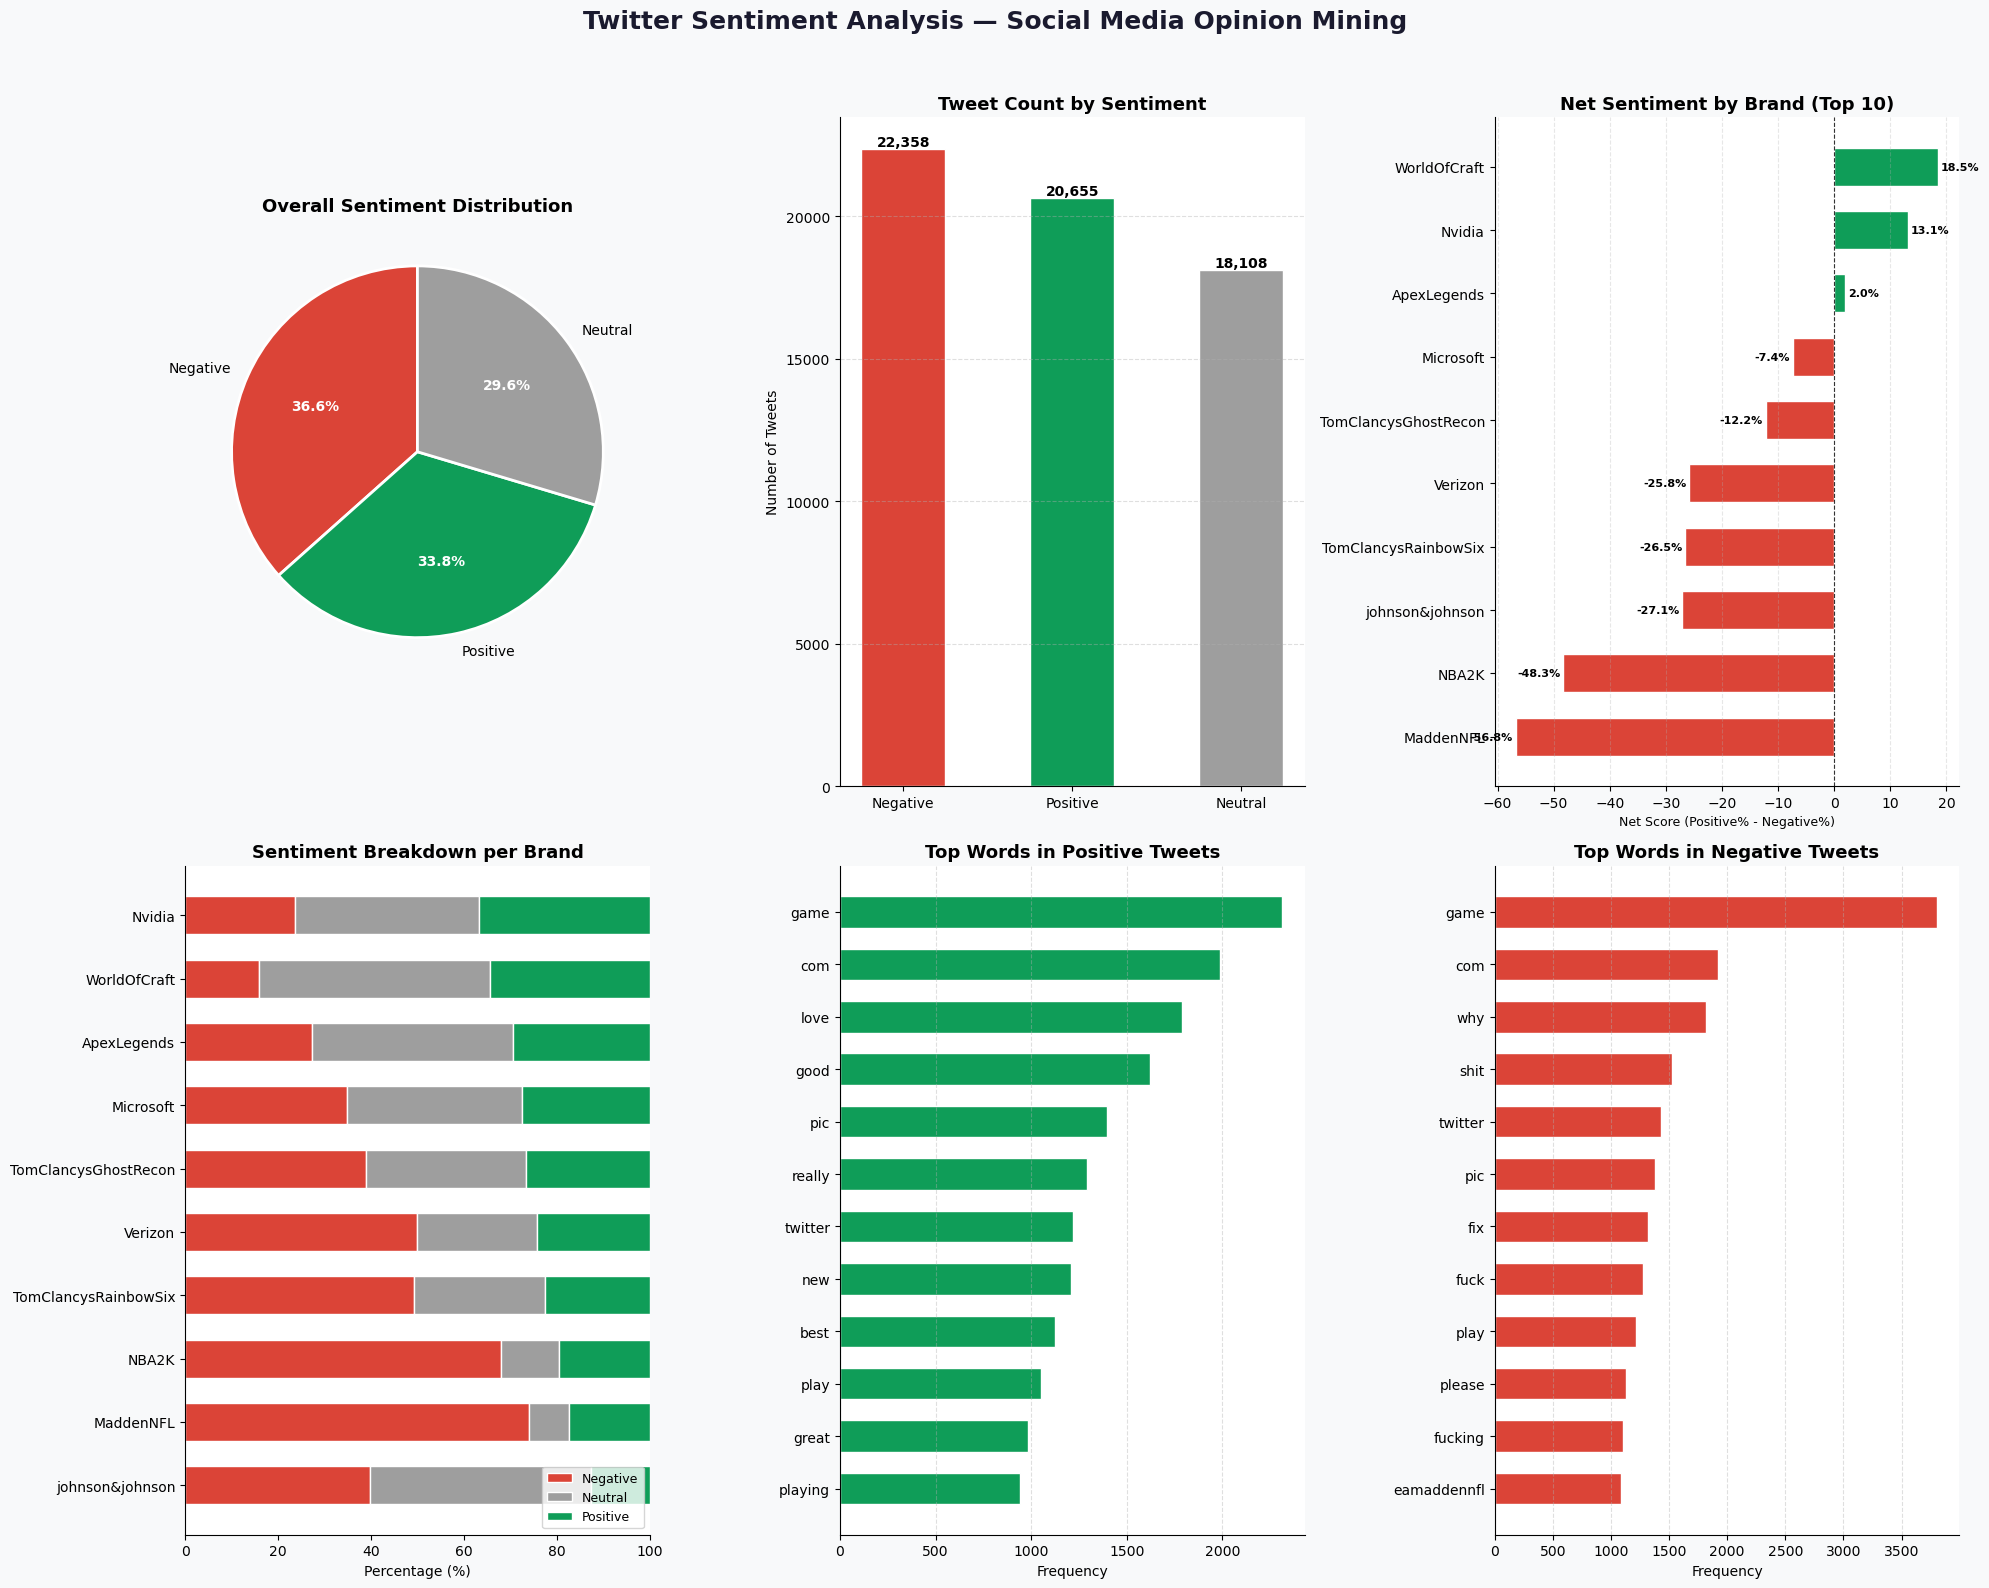

Done!


In [1]:
# ============================================================
# PRODIGY INFOTECH — Data Science Internship
# Task 04: Sentiment Analysis on Twitter Data
# Dataset: Twitter Entity Sentiment Analysis — Kaggle
# Author: Edmond Wehbe
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD DATA ─────────────────────────────────────────────
file_path = r"C:\Users\Lenovo\OneDrive\Desktop\task4-prodigy\twitter_training.csv"
df = pd.read_csv(file_path, header=None)
df.columns = ['id', 'brand', 'sentiment', 'text']

# ── 2. CLEAN DATA ─────────────────────────────────────────────
df = df[df['sentiment'] != 'Irrelevant'].dropna(subset=['text'])
df['text'] = df['text'].astype(str)

print(f"Total tweets: {len(df):,}")
print(f"\nSentiment counts:\n{df['sentiment'].value_counts()}")
print(f"\nBrands: {df['brand'].nunique()}")

# ── 3. COLORS ─────────────────────────────────────────────────
GREEN  = '#0F9D58'; RED    = '#DB4437'
GRAY   = '#9E9E9E'; BLUE   = '#1A73E8'
SENT_COLORS = {'Positive': GREEN, 'Negative': RED, 'Neutral': GRAY}

# ── 4. DERIVED DATA ───────────────────────────────────────────
sent_counts = df['sentiment'].value_counts()

# Top 10 brands
top_brands = df['brand'].value_counts().head(10).index.tolist()
brand_df   = df[df['brand'].isin(top_brands)]
brand_sent = brand_df.groupby(
    ['brand','sentiment']).size().unstack(fill_value=0)
brand_sent_pct = brand_sent.div(brand_sent.sum(axis=1), axis=0) * 100
brand_sent_pct['net'] = (brand_sent_pct.get('Positive', 0)
                         - brand_sent_pct.get('Negative', 0))
brand_net = brand_sent_pct['net'].sort_values()

# Top words per sentiment
def get_top_words(sentiment, n=12):
    stopwords = {
        'i','the','a','to','and','is','in','it','of','for','on',
        'my','me','you','that','this','with','was','be','are','at',
        'an','so','we','but','not','have','just','do','if','as',
        'can','will','all','from','they','he','she','your','its',
        'about','what','get','got','im','or','am','had','has','been',
        'their','our','when','up','out','no','by','more','one','would',
        'like','than','there','her','him','some','who','how','his',
        'into','also','very','after','time','were','now','did',
        're','s','t','https','nan'
    }
    texts = df[df['sentiment']==sentiment]['text'].str.lower()
    words = []
    for t in texts:
        words += [w for w in re.findall(r'\b[a-z]{3,}\b', t)
                  if w not in stopwords]
    return pd.Series(words).value_counts().head(n)

pos_words = get_top_words('Positive')
neg_words  = get_top_words('Negative')

# ── 5. PLOT ───────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('Twitter Sentiment Analysis — Social Media Opinion Mining',
             fontsize=18, fontweight='bold', y=0.99, color='#1A1A2E')

# Chart 1 — Pie chart
ax1 = fig.add_subplot(2, 3, 1)
ax1.set_facecolor('#FFFFFF')
colors_pie = [SENT_COLORS[s] for s in sent_counts.index]
wedges, texts, autotexts = ax1.pie(
    sent_counts.values, labels=sent_counts.index,
    colors=colors_pie, autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold'); at.set_color('white')
ax1.set_title('Overall Sentiment Distribution', fontsize=13, fontweight='bold')

# Chart 2 — Bar count
ax2 = fig.add_subplot(2, 3, 2)
ax2.set_facecolor('#FFFFFF')
bars2 = ax2.bar(sent_counts.index, sent_counts.values,
                color=[SENT_COLORS[s] for s in sent_counts.index],
                edgecolor='white', width=0.5)
ax2.set_ylabel('Number of Tweets', fontsize=10)
ax2.set_title('Tweet Count by Sentiment', fontsize=13, fontweight='bold')
ax2.spines[['top','right']].set_visible(False)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
for bar, val in zip(bars2, sent_counts.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
             f'{val:,}', ha='center', fontweight='bold', fontsize=10)

# Chart 3 — Net sentiment by brand
ax3 = fig.add_subplot(2, 3, 3)
ax3.set_facecolor('#FFFFFF')
colors_net = [GREEN if v >= 0 else RED for v in brand_net.values]
bars3 = ax3.barh(brand_net.index, brand_net.values,
                 color=colors_net, edgecolor='white', height=0.6)
ax3.axvline(0, color='#333', linewidth=0.8, linestyle='--')
ax3.set_xlabel('Net Score (Positive% - Negative%)', fontsize=9)
ax3.set_title('Net Sentiment by Brand (Top 10)', fontsize=13, fontweight='bold')
ax3.spines[['top','right']].set_visible(False)
ax3.grid(axis='x', linestyle='--', alpha=0.3)
for bar, val in zip(bars3, brand_net.values):
    xpos = bar.get_width()+0.5 if val >= 0 else bar.get_width()-0.5
    ax3.text(xpos, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8, fontweight='bold',
             ha='left' if val >= 0 else 'right')

# Chart 4 — Stacked sentiment per brand
ax4 = fig.add_subplot(2, 3, 4)
ax4.set_facecolor('#FFFFFF')
brands_sorted = brand_sent_pct.sort_values('Positive', ascending=True)
left = np.zeros(len(brands_sorted))
for sent, color in zip(['Negative','Neutral','Positive'], [RED, GRAY, GREEN]):
    if sent in brands_sorted.columns:
        vals = brands_sorted[sent].values
        ax4.barh(brands_sorted.index, vals, left=left,
                 color=color, edgecolor='white', height=0.6, label=sent)
        left += vals
ax4.set_xlabel('Percentage (%)', fontsize=10)
ax4.set_title('Sentiment Breakdown per Brand', fontsize=13, fontweight='bold')
ax4.legend(loc='lower right', fontsize=9)
ax4.spines[['top','right']].set_visible(False)
ax4.set_xlim(0, 100)

# Chart 5 — Top positive words
ax5 = fig.add_subplot(2, 3, 5)
ax5.set_facecolor('#FFFFFF')
ax5.barh(pos_words.index[::-1], pos_words.values[::-1],
         color=GREEN, edgecolor='white', height=0.6)
ax5.set_xlabel('Frequency', fontsize=10)
ax5.set_title('Top Words in Positive Tweets', fontsize=13, fontweight='bold')
ax5.spines[['top','right']].set_visible(False)
ax5.grid(axis='x', linestyle='--', alpha=0.4)

# Chart 6 — Top negative words
ax6 = fig.add_subplot(2, 3, 6)
ax6.set_facecolor('#FFFFFF')
ax6.barh(neg_words.index[::-1], neg_words.values[::-1],
         color=RED, edgecolor='white', height=0.6)
ax6.set_xlabel('Frequency', fontsize=10)
ax6.set_title('Top Words in Negative Tweets', fontsize=13, fontweight='bold')
ax6.spines[['top','right']].set_visible(False)
ax6.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout(rect=[0,0,1,0.97])
plt.savefig('task04_sentiment_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Done!")